<a href="https://colab.research.google.com/github/akanksha726/Car-Market-Trends-Analysis/blob/main/Car_Dekho.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/akanksha726/Car-Market-Trends-Analysis.git

Cloning into 'Car-Market-Trends-Analysis'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), 7.28 KiB | 7.28 MiB/s, done.


In [ ]:
!ls Car-Market-Trends-Analysis

'Car Market Trends Analysis with Car Dekho Data.csv'   README.md


In [ ]:
%cd Car-Market-Trends-Analysis

/content/Car-Market-Trends-Analysis


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from plotly.offline import iplot
import plotly as py
import plotly.tools as tls
import cufflinks as cf
py.offline.init_notebook_mode(connected=True) #Turning on notebook mode
cf.go_offline()

In [ ]:
df=pd.read_csv("Car Market Trends Analysis with Car Dekho Data.csv")
df.shape

(301, 9)

In [ ]:
df.info

<bound method DataFrame.info of     Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Seller_Type Transmission  Owner  
0        Dealer       Manual      0  
1        Dealer       Manual      0  
2        Dealer       Manual      0  
3        Dealer       Manual      0  
4        Dealer       Manual      0  
..          ...          ...    ...  
296      Dealer       Manual      0  
297      Dealer       Manual      0  
298      Dealer       Manual      0  
299      Dealer       Manual      0  
300      Dealer       Manual      0  

[301 rows x 9 columns]>

In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


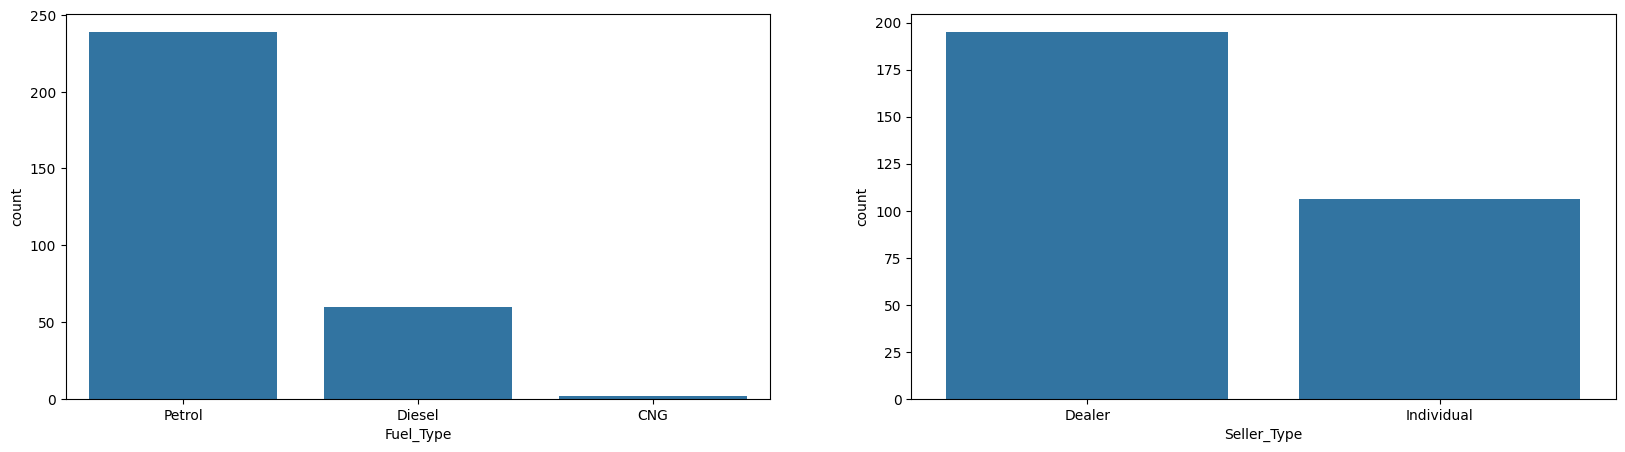

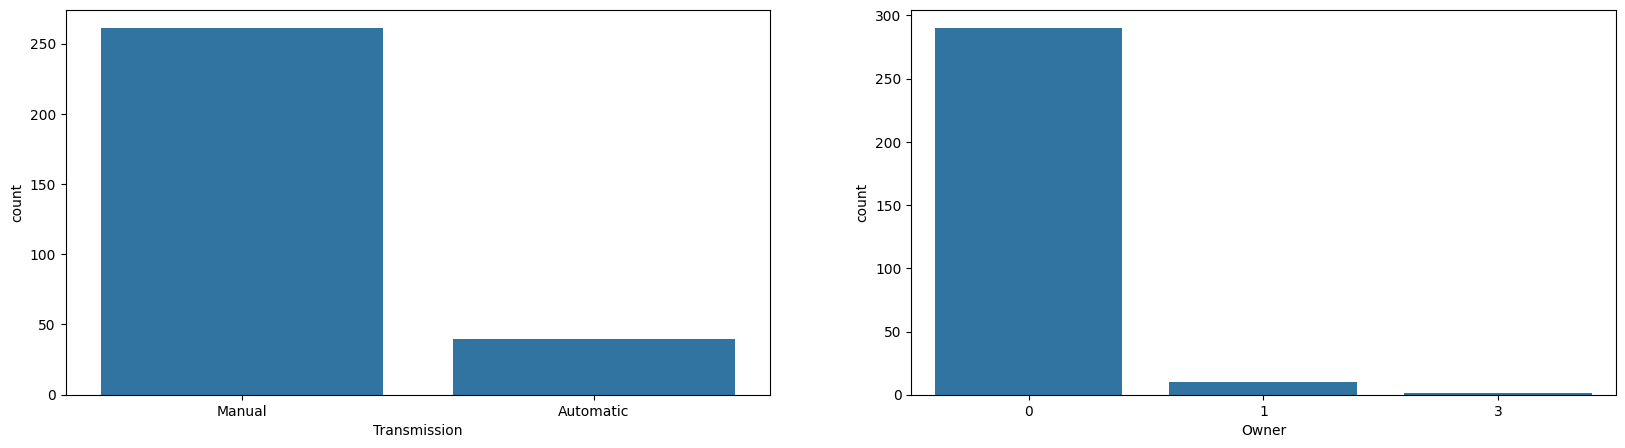

In [ ]:
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
i=0
while i < len(cat_cols):
    fig = plt.figure(figsize=[20,5])

    plt.subplot(1,2,1)
    sns.countplot(x=cat_cols[i], data =df)

    if i + 1 < len(cat_cols):
        plt.subplot(1,2,2)
        sns.countplot(x=cat_cols[i+1], data =df)

    plt.show()
    i+=2

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df[df['Selling_Price'] > df['Selling_Price'].quantile(0.99)].sort_values(by="Selling_Price",ascending=True)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
63,fortuner,2015,23.5,35.96,47000,Diesel,Dealer,Automatic,0
64,fortuner,2017,33.0,36.23,6000,Diesel,Dealer,Automatic,0
86,land cruiser,2010,35.0,92.60,78000,Diesel,Dealer,Manual,0


In [ ]:
Owner=df.groupby("Owner")
Owner.Selling_Price.mean().sort_values(ascending=False).iplot(Kind="bar")

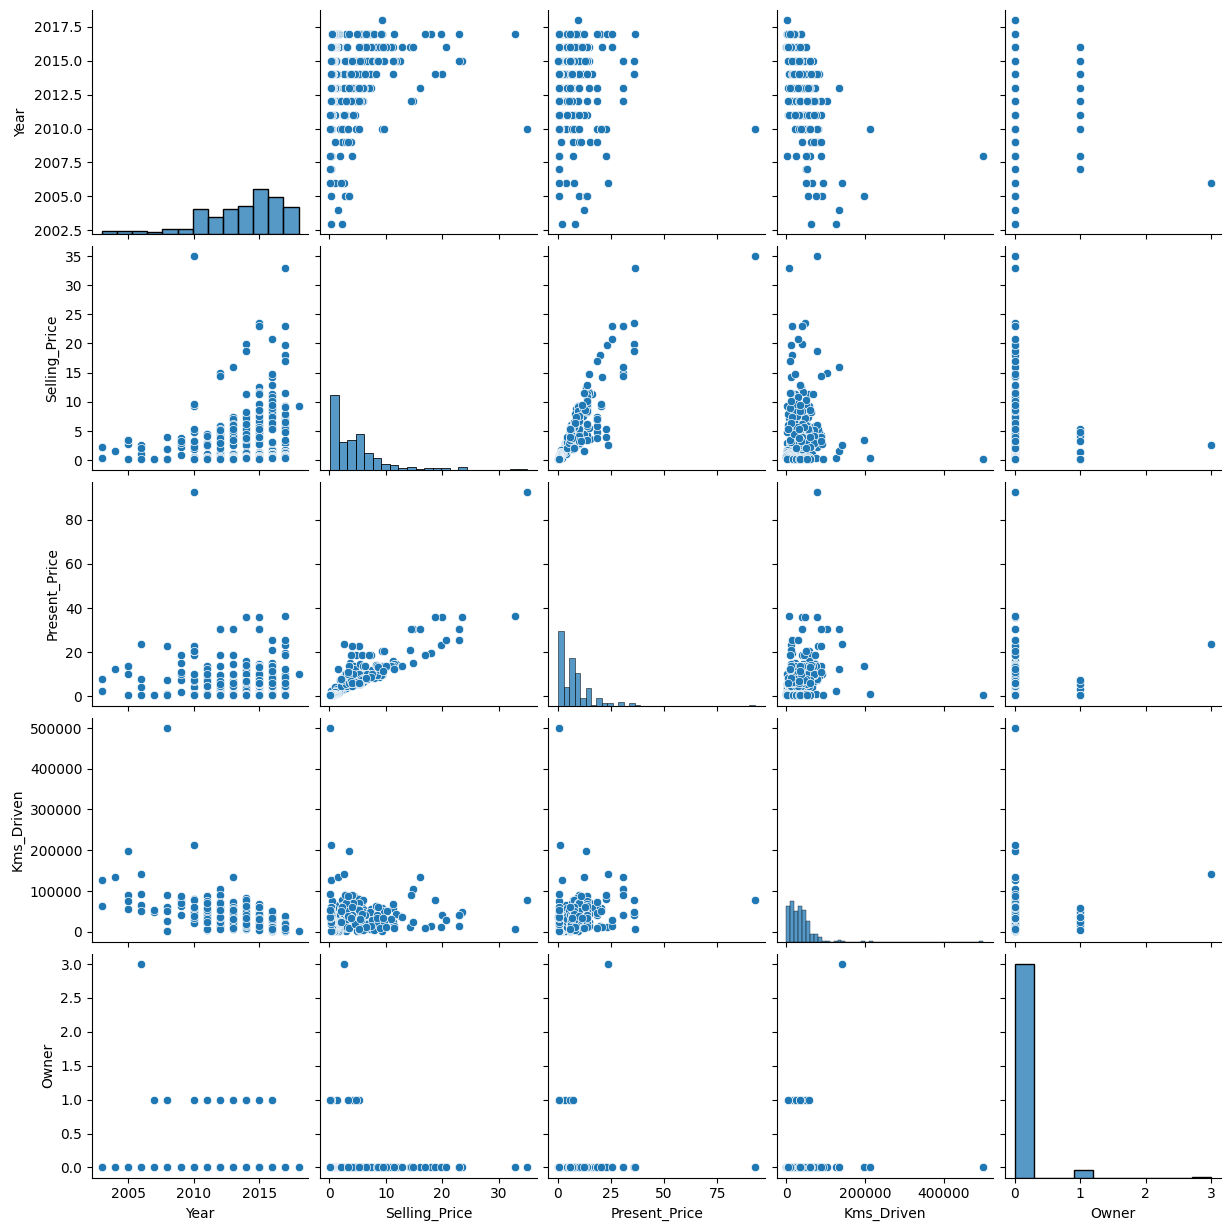

In [ ]:
sns.pairplot(df)

In [ ]:
Car_Name=df["Car_Name"].unique()

df["Car_Name"].nunique()

In [ ]:
pd.DataFrame(Car_Name)

,0
0,ritz
1,sx4
2,ciaz
3,wagon r
4,swift
...,...
93,verna
94,city
95,brio
96,amaze


In [ ]:
df['brand'] = df['Car_Name'].str.split('').str[0]
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,


In [ ]:
df.brand.unique()

array([''], dtype=object)

In [ ]:
df.brand.nunique()

1

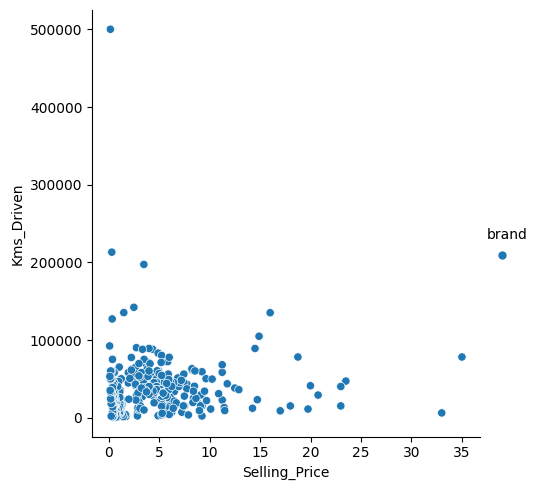

In [ ]:
sns.relplot(x=df.Selling_Price, y=df.Kms_Driven, hue= df.brand)

<Axes: ylabel='count'>

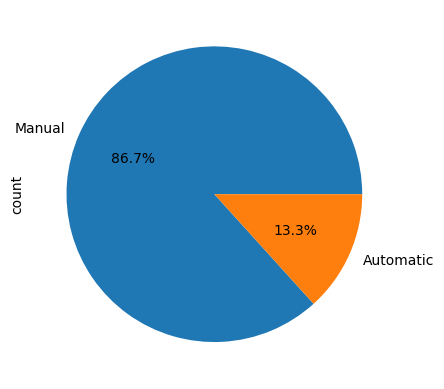

In [ ]:
df.Transmission.value_counts().plot.pie(autopct='%1.1f%%')

<Axes: ylabel='count'>

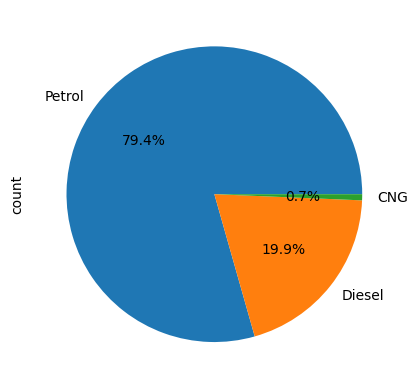

In [ ]:
df.Fuel_Type.value_counts().plot.pie(autopct='%1.1f%%')

<Axes: ylabel='count'>

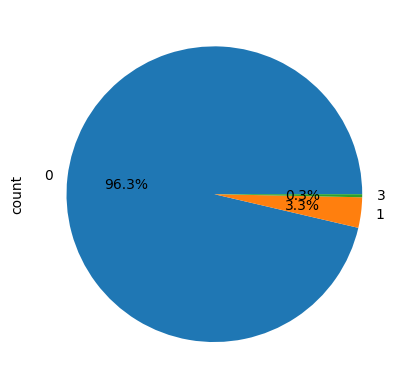

In [ ]:
df.Owner.value_counts().plot.pie(autopct='%1.1f%%')